<sub>Developed by SeongKu Kang, August 2025 — Do not distribute</sub>

# 1.a. Basic Input

Before I can manipulate and make a system for this task I need to understand what I'm working with.

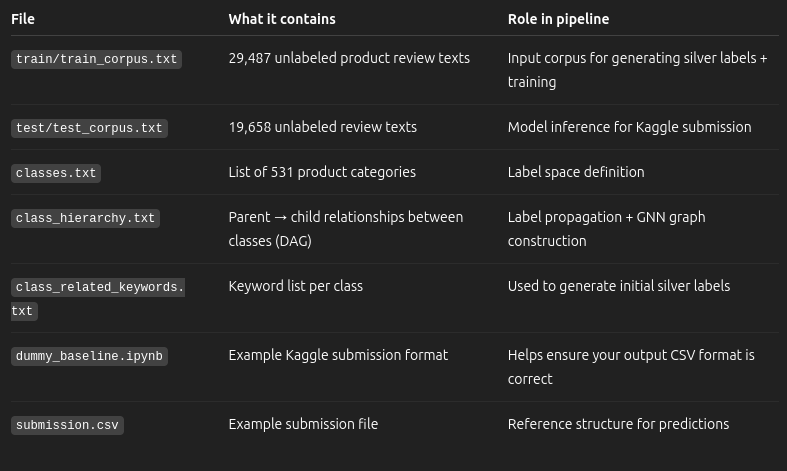

In [ ]:
from pathlib import Path
import numpy as np
from collections import defaultdict, Counter
import re



In [3]:
# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
TEST_CORPUS_PATH = ROOT / "Amazon_products" / "test" / "test_corpus.txt"

CLASSES_PATH = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH = ROOT / "Amazon_products" / "class_related_keywords.txt"

In [ ]:
# train_corpus.txt
# Represents the reviews that we will train with later


with open(TRAIN_CORPUS_PATH, "r") as f:
    for _ in range(5):
        print(next(f).strip())

"""
review id / review - structure
"""

with open(TRAIN_CORPUS_PATH, "r") as f:
    reviews = [line.strip().split("\t", 1)[1] for line in f]

lengths = np.array([len(r.split()) for r in reviews])

print("Total reviews:", len(lengths))
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("Std dev:", np.std(lengths))
print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))

# Useful percentiles
for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(lengths, p))


# Run training on train_corpus.txt
# Use the model on test_corpus.txt 
# Evaluate with kaggle
# Possibly split train_corpus into 80% training -> 20% validation. Then maybe you can get a rough estimate but it will hinge upon the success on the silver labels

# test_corpus.txt

with open(TEST_CORPUS_PATH, "r") as f:
    for _ in range(5):
        print(next(f).strip())


0	omron hem 790it automatic blood pressure monitor with advanced omron health management software so far this machine has worked well and is very simple to use . it is nice to have immediate feedback on the bloodpressure effects of my various exercises , food consumption , and relaxation or stress levels .
1	natural factors whey factors chocolate works well , but there is a lot of dead space in the container when you first open it up . the container comes 3 4 4 5 full and the rest in empty space .
2	clif bar builder 's bar , 2 . 4 ounce bars i love the peanut butter builder 's bars . while amazon is great for so many things , a trip to tj 's is too good to pass up . a little cup of coffee , a sample or two and into the cart with some fresh vegetables and whatever else is irresistible that day . life does n't get much better . if tj 's were n't local ( perish the thought ! ) , i 'd order the bars from amazon . with amazon 's sales volume , 2 day fedex delivery and a sheltered place for 

In [ ]:
# classes.txt
# Represents the different categories that we will match each review 2
# Represents all product categories. Each review can belong to multiple classes, and if it belongs to a sub-class, it must also belong to its parent class.
# Notice broad variation. Assuming amazon products which can vary drastically in function and theme

with open(CLASSES_PATH, "r") as f:
    classes = [line.strip() for line in f]

print("Total classes:", len(classes))
print("\nFirst 15 classes:")
for c in classes[:15]:
    print(c)

"""
Example -
grocery_gourmet_food
 ├─ meat_poultry
 │   └─ jerky
toys_games
 ├─ games
 │   ├─ puzzles
 │   │   └─ jigsaw_puzzles
 │   └─ board_games
beverages
 └─ juices
beauty
 └─ makeup
     └─ nails
arts_crafts
 └─ drawing_painting_supplies
"""


Total classes: 531

First 15 classes:
0	grocery_gourmet_food
1	meat_poultry
2	jerky
3	toys_games
4	games
5	puzzles
6	jigsaw_puzzles
7	board_games
8	beverages
9	juices
10	beauty
11	makeup
12	nails
13	arts_crafts
14	drawing_painting_supplies


In [ ]:
# class_hierarchy.txt
# <parent_index>  <child_index> format
# It is simply mapping the hierarchical structure


with open(HIERARCHY_PATH, "r") as f:
    for _ in range(15):
        print(next(f).strip())



# More visual representation. We see all children of class 0
graph = defaultdict(list)

with open(HIERARCHY_PATH, "r") as f:
    for line in f:
        parent, child = map(int, line.strip().split("\t"))
        graph[parent].append(child)

print("Children of class 0:", graph[0])



0	1
0	8
0	208
0	211
0	213
0	216
0	229
0	255
0	265
0	218
0	271
0	277
0	249
0	288
0	313
Children of class 0: [1, 8, 208, 211, 213, 216, 229, 255, 265, 218, 271, 277, 249, 288, 313, 357]


In [ ]:
#class_related_keywords.txt
# So exactly as the name of the file suggests, this file contains relevant keywords for any class
# This essentially creates a bridge between the class and the review. 
with open(KEYWORDS_PATH, "r") as f:
    for _ in range(10):
        print(next(f).strip())



#Below to confirm keyword duplicates exists. This means that the system might have to rank them somehow
# Load keywords
class_keywords = {}
all_keywords = []

with open(KEYWORDS_PATH, "r") as f:
    for line in f:
        class_name, keywords_str = line.strip().split(":")
        keywords = keywords_str.split(",")
        class_keywords[class_name] = keywords
        all_keywords.extend(keywords)

# 1. Check duplicates within each class
for cls, kws in class_keywords.items():
    dup = [k for k, c in Counter(kws).items() if c > 1]
    if dup:
        print(f"Duplicate keywords in class {cls}: {dup}")

# 2. Check keywords appearing in multiple classes
keyword_to_classes = defaultdict(list)
for cls, kws in class_keywords.items():
    for kw in kws:
        keyword_to_classes[kw].append(cls)

multi_class_keywords = {kw: cls_list for kw, cls_list in keyword_to_classes.items() if len(cls_list) > 1}
print("Keywords appearing in multiple classes:", multi_class_keywords)


grocery_gourmet_food:snacks,condiments,beverages,specialty_foods,spices,cooking_oils,baking_ingredients,gourmet_chocolates,artisanal_cheeses,organic_foods
meat_poultry:butcher,cuts,marination,grilling,roasting,seasoning,halal,organic,deli,marbling
jerky:beef,turkey,chicken,venison,buffalo,kangaroo,elk,ostrich,bison,spicy
toys_games:board_games,puzzles,action_figures,building_blocks,dolls,outdoor_toys,educational_toys,card_games,remote_control_toys,plush_toys
games:board_games,card_games,tabletop_games,party_games,roleplaying_games,video_games,strategy_games,family_games,word_games,dice_games
puzzles:jigsaw_puzzles,brain_teasers,puzzle_accessories,puzzle_storage,puzzle_mats,puzzle_glue,puzzle_organizers,puzzle_books,puzzle_magazines,puzzle_competitions
jigsaw_puzzles:interlocking_pieces,puzzle_boards,puzzle_glue,puzzle_storage,puzzle_frames,puzzle_rolls,puzzle_organizers,puzzle_tables,puzzle_sleeves,puzzle_sorting_trays
board_games:board_game_accessories,strategy_games,cooperative_games

# 1.b. Input Conversion

The input need to be made readable by the system first. Lets look at what happens as we build dictionaries and whatnot

In [ ]:
# Load and sanitize class names
# Idea here is to map Mapping names to indices


classes = []
with open(CLASSES_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split("\t")  # split on tab
        if len(parts) == 2:
            idx, name = parts
            classes.append(name.strip().lower())  # keep only the class name

# Build mappings
idx_to_class = {i: name for i, name in enumerate(classes)}
class_to_idx = {name: i for i, name in enumerate(classes)}

# Example check
print("Total classes:", len(classes))
print("Class index 0:", idx_to_class[0])
print("Index of 'jerky':", class_to_idx.get('jerky', "Not found"))




Total classes: 531
Class index 0: grocery_gourmet_food
Index of 'jerky': 2


In [ ]:
#Step 2: Load and Sanitize Hierarchy
# Convert raw parent-child index pairs into dictionaries for easy traversal:
# - children_map[parent_idx] gives all child indices
# - parents_map[child_idx] gives all parent indices
# - Provides a foundation for silver-label generation and hierarchical classification


# Initialize empty maps
children_map = defaultdict(list)
parents_map = defaultdict(list)

# Load hierarchy file
with open(HIERARCHY_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            parent_idx, child_idx = map(int, parts)  # convert to int
            children_map[parent_idx].append(child_idx)
            parents_map[child_idx].append(parent_idx)

# Example checks
print("Children of class 0:", [idx_to_class[i] for i in children_map[0]])
print("Parents of class 2:", [idx_to_class[i] for i in parents_map[2]])


Children of class 0: ['meat_poultry', 'beverages', 'gourmet_gifts', 'sauces_dips', 'breakfast_foods', 'pantry_staples', 'fresh_flowers_live_indoor_plants', 'breads_bakery', 'candy_chocolate', 'cooking_baking_supplies', 'snack_food', 'meat_seafood', 'herbs', 'baby_food', 'dairy_eggs', 'produce']
Parents of class 2: ['meat_poultry']


In [13]:
# Step 3: Load class-related keywords
# Sanitize keywords

class_keywords = {}

with open(KEYWORDS_PATH, "r", encoding="utf8") as f:
    for line in f:
        # Split on colon to separate class name from keyword string
        parts = line.strip().split(":")
        cls = parts[0].strip().lower()  # sanitize class name
        kws = parts[1] if len(parts) > 1 else ""
        # Split keywords on comma, strip whitespace, convert to lowercase
        class_keywords[cls] = [k.strip().lower() for k in kws.split(",") if k]

# Example check
print("Keywords for 'jerky':", class_keywords.get('jerky', []))
print("Keywords for 'beverages':", class_keywords.get('beverages', []))

Keywords for 'jerky': ['beef', 'turkey', 'chicken', 'venison', 'buffalo', 'kangaroo', 'elk', 'ostrich', 'bison', 'spicy']
Keywords for 'beverages': ['coffee', 'tea', 'energy_drinks', 'soft_drinks', 'bottled_water', 'juices', 'sports_drinks', 'smoothies', 'iced_tea', 'coconut_water']


In [ ]:

# Function to load corpus as {id: text}
def load_corpus_plaintext(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: line.strip() for i, line in enumerate(f)}

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()                       # lowercase
    text = re.sub(r"[^a-z0-9\s]", " ", text) # remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # normalize spaces
    return text

# Load corpora
train_pid2text = load_corpus_plaintext(TRAIN_CORPUS_PATH)
test_pid2text = load_corpus_plaintext(TEST_CORPUS_PATH)

# Apply preprocessing
train_pid2text = {pid: preprocess_text(text) for pid, text in train_pid2text.items()}
test_pid2text = {pid: preprocess_text(text) for pid, text in test_pid2text.items()}

# Convert to aligned lists if needed for models
def dict2list(id2text):
    ids = list(id2text.keys())
    texts = [id2text[i] for i in ids]
    return ids, texts

train_ids, train_texts = dict2list(train_pid2text)
test_ids, test_texts = dict2list(test_pid2text)

# Example outputs
print("First train review:", train_texts[0])
print("First test review:", test_texts[0])
